### 1.
#### a)

In [ ]:
!pip install kagglehub -q

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
dataset path: /kaggle/input/dog-and-cat-classification-dataset
extraindo descritores
amostras carregadas: 1972
treinando SVM 
isso pode demorar alguns segundos
acurácia: 65.71%


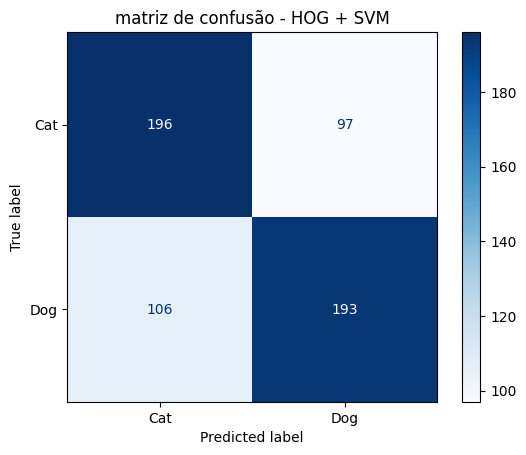

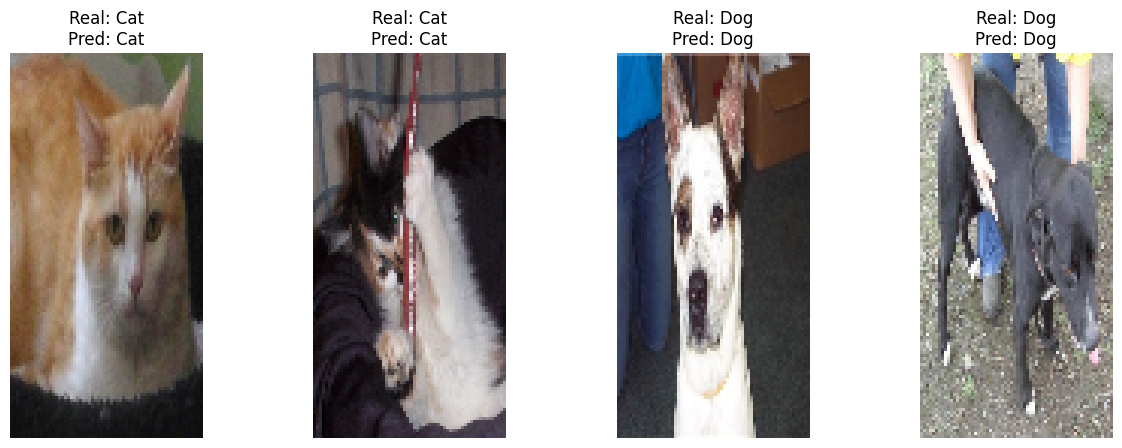

In [ ]:
import kagglehub
import cv2
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
print("dataset path:", path)

dataset_path = path
class_names = ['Cat', 'Dog']

def extract_hog_features(image_path):
    img = cv2.imread(image_path)
    if img is None or img.size == 0:
        return None, None
    img = cv2.resize(img, (64, 128))
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    hog = cv2.HOGDescriptor()
    features = hog.compute(gray)
    return features.flatten(), img

X_hog, y_hog, images_hog = [], [], []

print("extraindo descritores")
for label, class_name in enumerate(class_names):
    paths = glob.glob(os.path.join(dataset_path, '**', class_name, '*.*'), recursive=True)
    if not paths:
        paths = glob.glob(os.path.join(dataset_path, class_name, '*.*'))

    for p in paths[:986]:
        features, img = extract_hog_features(p)
        if features is not None:
            X_hog.append(features)
            y_hog.append(label)
            images_hog.append(img)

X_hog = np.array(X_hog)
y_hog = np.array(y_hog)

print(f"amostras carregadas: {len(X_hog)}")

X_train, X_test, y_train, y_test, img_train, img_test = train_test_split(
    X_hog, y_hog, images_hog, test_size=0.30, random_state=42
)

print("treinando SVM \nisso pode demorar alguns segundos")
svm_clf = SVC(kernel='linear', C=1.0)
svm_clf.fit(X_train, y_train)

y_pred = svm_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"acurácia: {acc * 100:.2f}%")

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("matriz de confusão - HOG + SVM")
plt.show()

fig, axes = plt.subplots(1, 4, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(cv2.cvtColor(img_test[i], cv2.COLOR_BGR2RGB))
    ax.set_title(f"Real: {class_names[y_test[i]]}\nPred: {class_names[y_pred[i]]}")
    ax.axis('off')
plt.show()

#### b)

Using Colab cache for faster access to the 'dog-and-cat-classification-dataset' dataset.
qnt. imagens utilizadas: 1000
distribuição total:
class
Cat    500
Dog    500
Name: count, dtype: int64

Treino  : 700 imagens
  Cat   : 350
  Dog   : 350

Teste   : 300 imagens
  Cat   : 150
  Dog   : 150
Found 700 validated image filenames belonging to 2 classes.
Found 300 validated image filenames belonging to 2 classes.

 treinando modelo: VGG16
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 524s 24s/step - accuracy: 0.6529 - loss: 0.6172 - val_accuracy: 0.6500 - val_loss: 0.5887
Epoch 2/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 523s 24s/step - accuracy: 0.7900 - loss: 0.4896 - val_accuracy: 0.7700 - val_loss: 0.4773
Epoch 3/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 566s 26s/step - accuracy: 0.8486 - loss: 0.4012 - val_accuracy: 0.8200 - val_loss: 0.4131
10/10 ━━━━━━━━━━━━━━━━━━━━ 158s 16s/step

acurácia VGG16: 82.00%


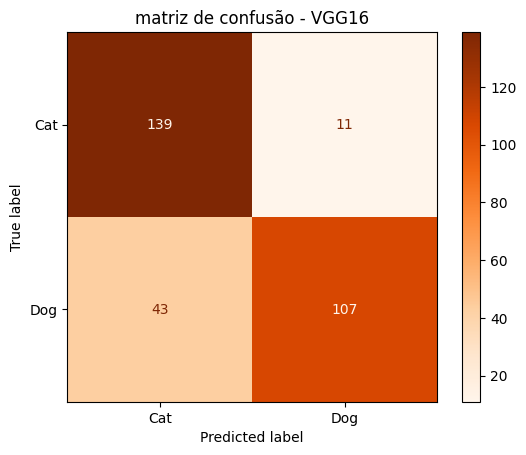


 treinando modelo: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 205s 9s/step - accuracy: 0.5100 - loss: 0.7121 - val_accuracy: 0.5200 - val_loss: 0.6981
Epoch 2/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 165s 7s/step - accuracy: 0.5786 - loss: 0.6656 - val_accuracy: 0.5700 - val_loss: 0.6806
Epoch 3/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 158s 7s/step - accuracy: 0.6314 - loss: 0.6423 - val_accuracy: 0.5700 - val_loss: 0.6950
10/10 ━━━━━━━━━━━━━━━━━━━━ 52s 5s/step

acurácia ResNet50: 57.00%


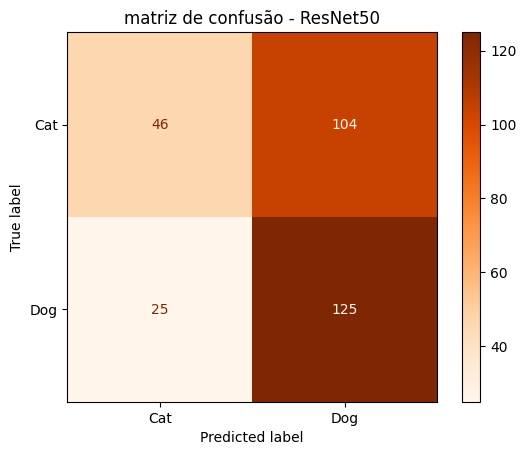


 treinando modelo: MobileNetV2
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 62s 2s/step - accuracy: 0.9443 - loss: 0.1306 - val_accuracy: 0.9633 - val_loss: 0.1127
Epoch 2/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.9957 - loss: 0.0137 - val_accuracy: 0.9767 - val_loss: 0.0638
Epoch 3/3
22/22 ━━━━━━━━━━━━━━━━━━━━ 42s 2s/step - accuracy: 1.0000 - loss: 0.0067 - val_accuracy: 0.9800 - val_loss: 0.0565
10/10 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step

acurácia MobileNetV2: 98.00%


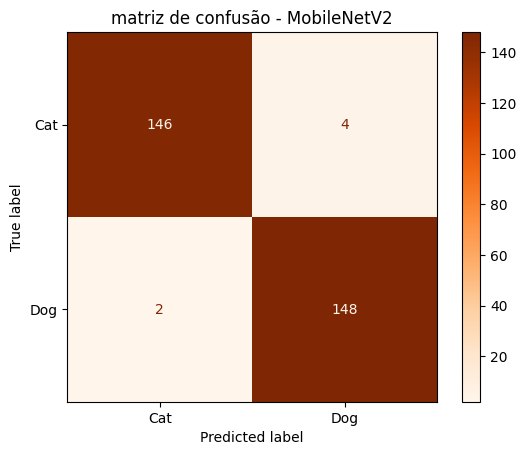

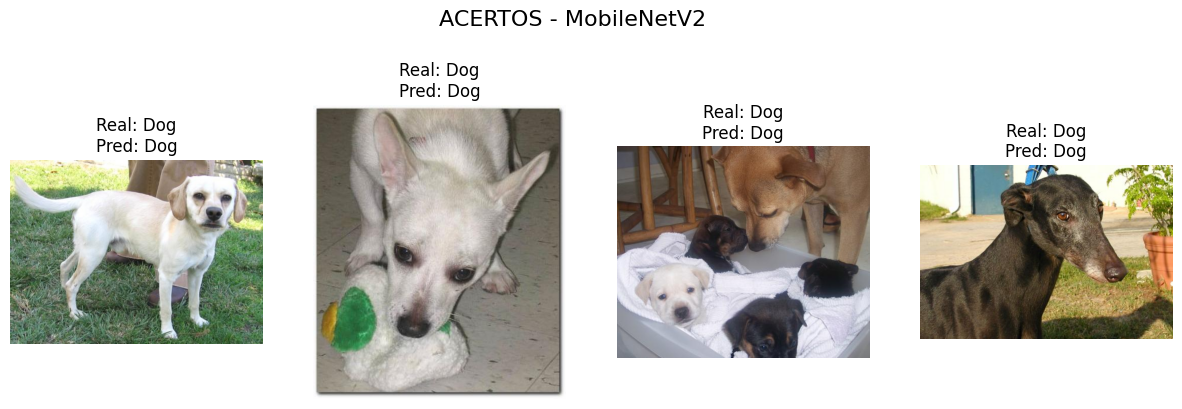

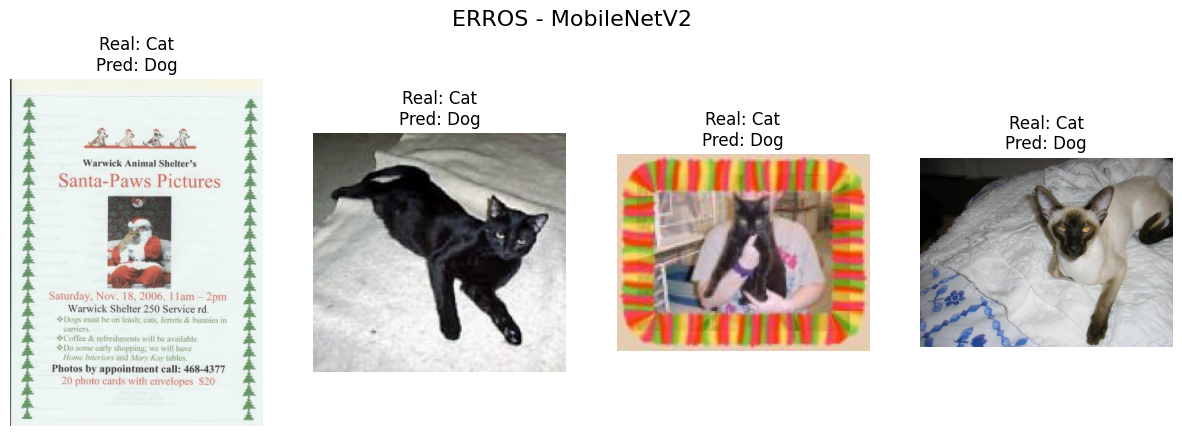

In [ ]:
import kagglehub
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

path = kagglehub.dataset_download("bhavikjikadara/dog-and-cat-classification-dataset")
dataset_path = path
class_names = ['Cat', 'Dog']
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

LIMITE_CLASSE = 500

filepaths = []
labels = []

for class_name in class_names:
    paths = glob.glob(os.path.join(dataset_path, '**', class_name, '*.*'), recursive=True)
    if not paths:
        paths = glob.glob(os.path.join(dataset_path, class_name, '*.*'))

    valid_count = 0
    for p in paths:
        if os.path.getsize(p) > 0 and p.lower().endswith(('.png', '.jpg', '.jpeg')):
            filepaths.append(p)
            labels.append(class_name)
            valid_count += 1

        if valid_count >= LIMITE_CLASSE:
            break

df = pd.DataFrame({'filename': filepaths, 'class': labels})
print(f"qnt. imagens utilizadas: {len(df)}")
print(f"distribuição total:\n{df['class'].value_counts()}")
df_train, df_test = train_test_split(
    df,
    test_size=0.30,
    random_state=42,
    stratify=df['class']
)

print(f"\nTreino  : {len(df_train)} imagens")
print(f"  Cat   : {(df_train['class'] == 'Cat').sum()}")
print(f"  Dog   : {(df_train['class'] == 'Dog').sum()}")
print(f"\nTeste   : {len(df_test)} imagens")
print(f"  Cat   : {(df_test['class'] == 'Cat').sum()}")
print(f"  Dog   : {(df_test['class'] == 'Dog').sum()}")

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    x_col='filename',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_gen = test_datagen.flow_from_dataframe(
    dataframe=df_test,
    x_col='filename',
    y_col='class',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)


def train_evaluateCNN(base_model_class, model_name):
    print(f"\n treinando modelo: {model_name}")

    base_model = base_model_class(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
    base_model.trainable = False

    model = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

    history = model.fit(train_gen, epochs=3, validation_data=test_gen)

    y_pred_probs = model.predict(test_gen)
    y_pred = (y_pred_probs > 0.5).astype(int).flatten()
    y_true = test_gen.classes

    acc = accuracy_score(y_true, y_pred)
    print(f"\nacurácia {model_name}: {acc * 100:.2f}%")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(test_gen.class_indices.keys()))
    disp.plot(cmap=plt.cm.Oranges)
    plt.title(f"matriz de confusão - {model_name}")
    plt.show()

    return model, y_true, y_pred


model_vgg, true_vgg, pred_vgg     = train_evaluateCNN(VGG16,        "VGG16")
model_res, true_res, pred_res     = train_evaluateCNN(ResNet50,     "ResNet50")
model_mob, true_mob, pred_mob     = train_evaluateCNN(MobileNetV2,  "MobileNetV2")

filenames     = test_gen.filenames
class_labels  = list(test_gen.class_indices.keys())

acertos_idx = np.where(true_mob == pred_mob)[0]
erros_idx   = np.where(true_mob != pred_mob)[0]


def plot_examples(indices_list, title_text):
    n = min(4, len(indices_list))
    if n == 0:
        print(f"Nenhum exemplo para: {title_text}")
        return
    fig, axes = plt.subplots(1, n, figsize=(15, 5))
    if n == 1:
        axes = [axes]
    for i, idx in enumerate(indices_list[:4]):
        img_path = filenames[idx]
        img = plt.imread(img_path)
        if len(img.shape) == 2:
            axes[i].imshow(img, cmap='gray')
        else:
            axes[i].imshow(img)
        axes[i].set_title(f"Real: {class_labels[true_mob[idx]]}\nPred: {class_labels[pred_mob[idx]]}")
        axes[i].axis('off')
    fig.suptitle(title_text, fontsize=16)
    plt.show()


plot_examples(acertos_idx, "ACERTOS - MobileNetV2")
plot_examples(erros_idx,   "ERROS - MobileNetV2")

### 2.

In [ ]:
pip install -q ultralytics opencv-python matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 17.0 MB/s eta 0:00:00


In [ ]:
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO

# YOLOv8 pre-treinado
model = YOLO('yolov8m.pt')

video_path = 'bridge.mp4'
output_path = 'output_bridge.mp4'

# a) processamento e detecçao no video
cap = cv2.VideoCapture(video_path)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = int(cap.get(cv2.CAP_PROP_FPS))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

# armanezando contagem de veiculos por frame, e a lista de frame
contagem_por_frame = []
lista_frames = []
frame_atual = 0

total_veiculos = set()
total_por_classe = {2: set(), 3: set(), 5: set()}
nomes_classes = {2: 'Carro', 3: 'Moto', 5: 'Onibus'}

MIN_BUS_AREA_RATIO = 0.02
FRAME_AREA = width * height

print("iniciciando o processamento \nisso pode levar algum tempo")

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # realiza a detecção no frame atual
    # no dataset COCO, as classes para veículos são:
    # 2 (car)ddd
    # 3 (motorcycle)
    # 5 (bus)
    # 7 (truck)
    # nisso, o parâmetro 'classes ignora tudo que nao for veículo
    resultados = model.track(frame, classes=[2, 3, 5], persist=True, verbose=False, conf=0.40, iou=0.45, tracker="botsort.yaml")

    if resultados[0].boxes is not None and len(resultados[0].boxes) > 0:
        indices_validos = []
        for i, box in enumerate(resultados[0].boxes):
            if int(box.cls.item()) == 5:
                x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
                if ((x2 - x1) * (y2 - y1)) / FRAME_AREA >= MIN_BUS_AREA_RATIO:
                    indices_validos.append(i)
            else:
                indices_validos.append(i)
        resultados[0].boxes = resultados[0].boxes[indices_validos]

    num_veiculos = len(resultados[0].boxes) # conta veiculo por fram
    contagem_por_frame.append(num_veiculos)
    lista_frames.append(frame_atual)

    if resultados[0].boxes.id is not None:
        ids = resultados[0].boxes.id.cpu().numpy().astype(int)
        classes = resultados[0].boxes.cls.cpu().numpy().astype(int)
        for obj_id, obj_cls in zip(ids, classes):
            total_veiculos.add(obj_id)
            total_por_classe[obj_cls].add(obj_id)

    # bounding box pronta do yolo
    frame_anotado = resultados[0].plot()

    cv2.putText(frame_anotado, f"Atual: {num_veiculos}", (20, 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)
    cv2.putText(frame_anotado, f"Total: {len(total_veiculos)}", (20, 80), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

    y_inicial = height - 150
    cv2.putText(frame_anotado, "Total por classe:", (20, y_inicial), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    for i, (cls_id, nome) in enumerate(nomes_classes.items()):
        qtd = len(total_por_classe[cls_id])
        cv2.putText(frame_anotado, f"{nome}: {qtd}", (20, y_inicial + 30 * (i + 1)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

    out.write(frame_anotado)

    frame_atual += 1

cap.release()
out.release()
print(f"vídeo processado e salvo nessa mesma hora e nesse mesmo canal")

# b) plotagem
plt.figure(figsize=(12, 6))
plt.plot(lista_frames, contagem_por_frame, color='blue', linewidth=1.5, label='Veículos (carros onibus i motas)')

plt.title('quantidade de veículos detectados ao longo do tempo', fontsize=14)
plt.xlabel('tempo (nº quadro/frame)', fontsize=12)
plt.ylabel('quantidade de veículos', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()

plt.savefig('grafico.png')
print("gráfico salvo")
plt.show()

import base64
import subprocess
from IPython.display import HTML

output_h264 = 'outputh264.mp4'
subprocess.run(['ffmpeg', '-i', output_path, '-vcodec', 'libx264', output_h264, '-y'],
               stdout=subprocess.DEVNULL,
               stderr=subprocess.DEVNULL)
with open(output_h264, 'rb') as f:
    video_base64 = base64.b64encode(f.read()).decode()

HTML(f"""
<video width="960" controls autoplay loop>
  <source src="data:video/mp4;base64,{video_base64}" type="video/mp4">
</video>
""")

Output hidden; open in https://colab.research.google.com to view.